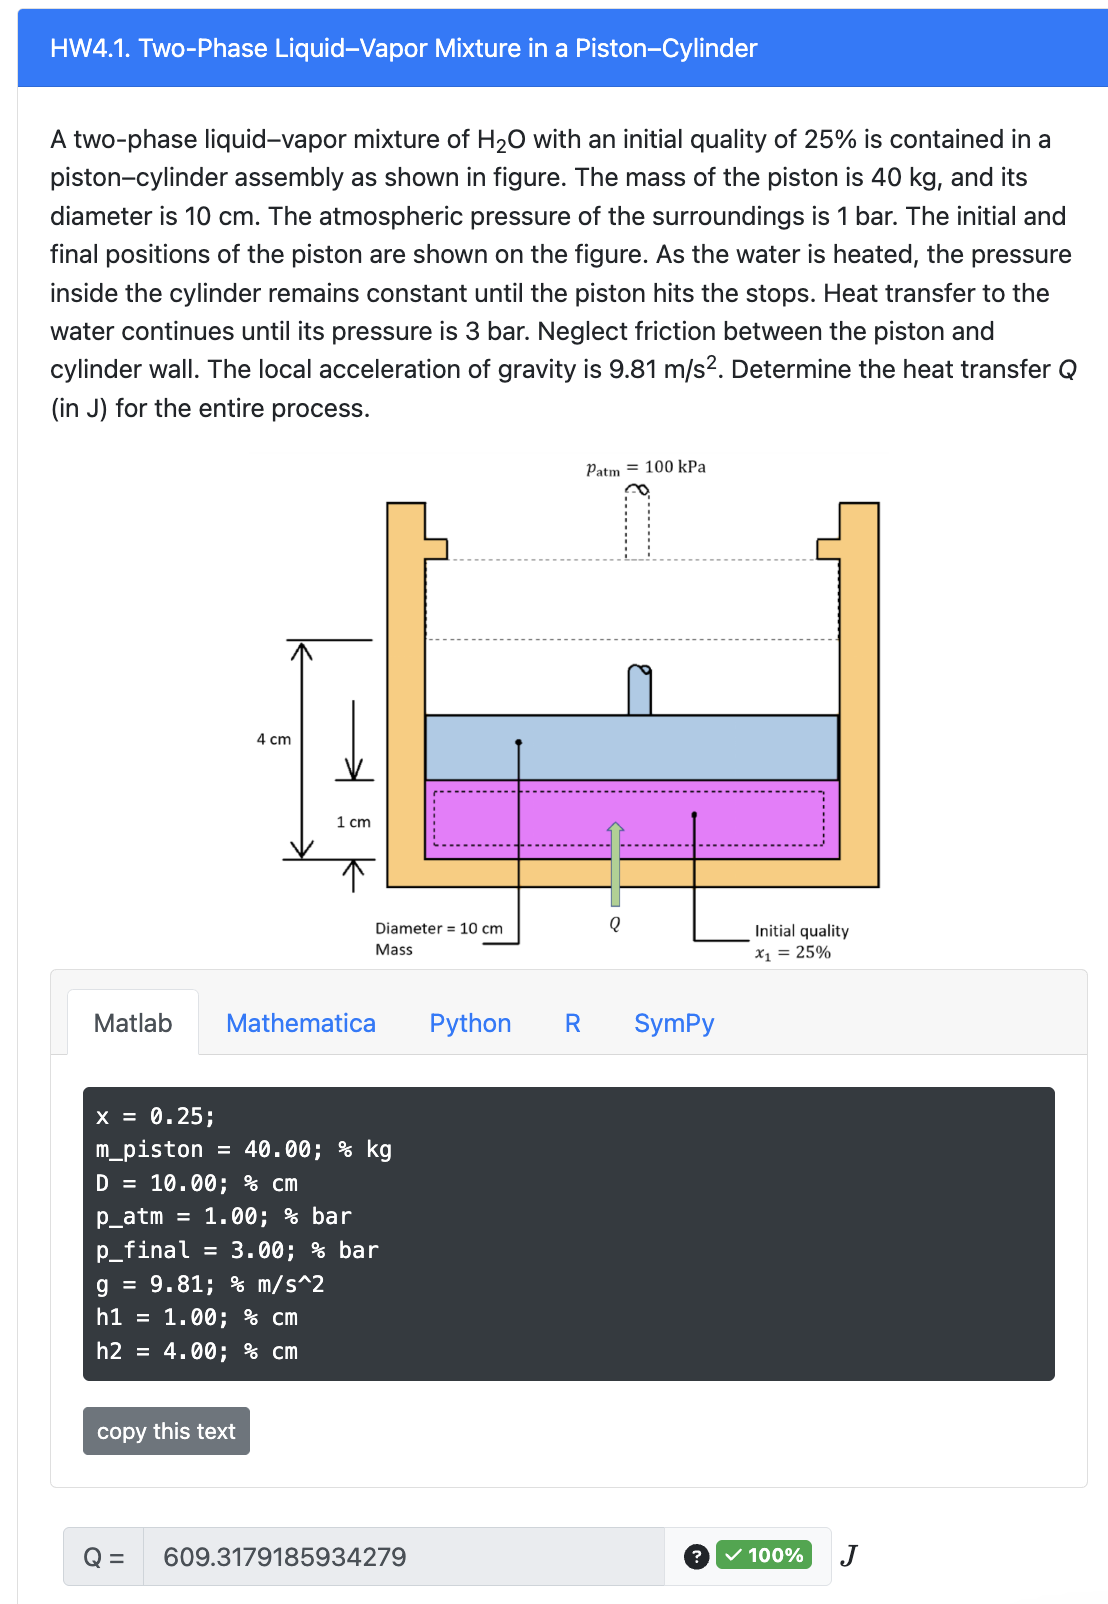

In [1]:
# 4.1

# 思路 
# 第一个 混合态 p1=p0+mg/s 查表得到v1 查表h1
# 第二个 算v2发现是superheated 查表h2

# m=v_1/v1
# Q12=(h2-h1)*m

from math import * 
import sympy as sy
import numpy as np

import numpy as np

x = 0.25
m_piston = 40.00 # kg
D = 10.00 # cm
p_atm = 1.00 # bar
p_final = 3.00 # bar
g = 9.81 # m/s^2
h1 = 1.00 # cm
h2 = 4.00 # cm

# ======================

D=D*1e-2
h1=h1*1e-2
h2=h2*1e-2



A=(D/2)**2*pi
p1=p_atm*1e5+m_piston*g/A
v1=x*1.159+(1-x)*0.0010528
h_1=x*2693.6+(1-x)*467.11
u_1=x*2519.7+(1-x)*466.94
print(float(v1))

v2=v1/h1*h2 
print(float(v2))
h_2=(v2-1.094)/(1.187-1.094)*(3486-3358.7)+3358.7
u_2=(v2-1.094)/(1.187-1.094)*(3130-3030.6)+3030.6

m=h1*A/v1



print((h_2-h_1)*m*1000)
print((u_2-u_1)*m*1000+(v2-v1)*m*p1)
# 按道理讲 上面应该也是对的，但是实际上答案只任下面


0.2905396
1.1621584
656.4179202671858
609.3179185934279


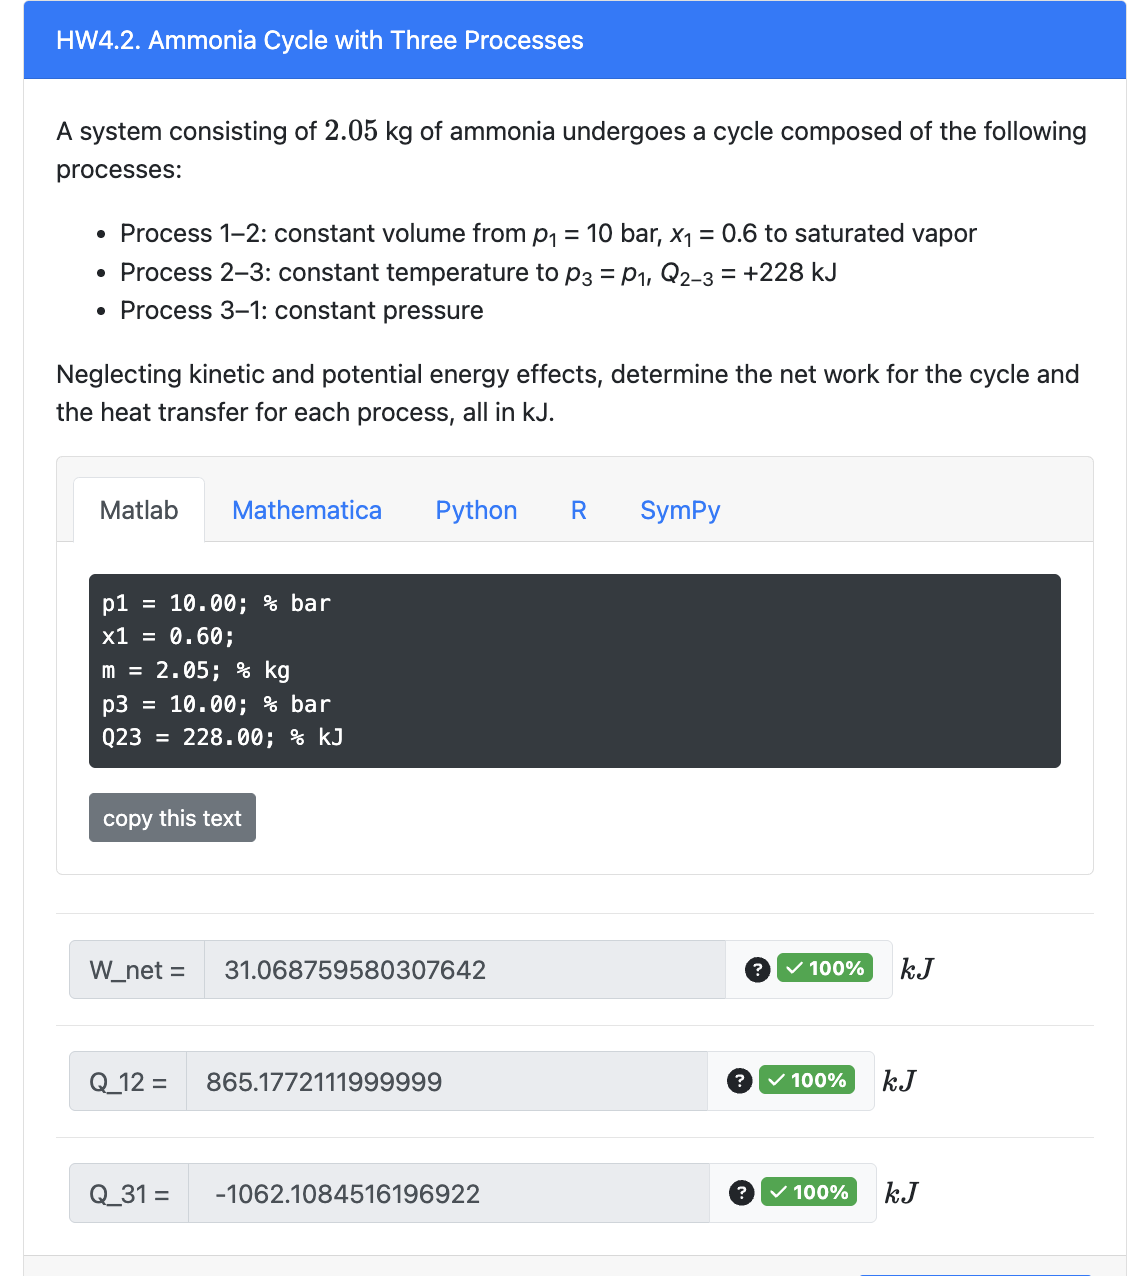

In [2]:
# 4.2
# 思路
# 第一阶段混合物 p1知道 x知道 算出v1,u1
# 第二阶段混合物变成气体 v2知道 读表找到t2，h2,u2
# 第三阶段气体 p3 t3知道 读表找到h3
# Q12=(u2-u1)*m
# Q31=(h1-h3)*m
# W=Q12+Q31+Q


import numpy as np

p1 = 10.00 # bar
x1 = 0.60
m = 1.25 # kg
p3 = 10.00 # bar
Q23 = 228.00 # kJ

p1=p1*1e5
p3=p3*1e5

# 读表
v1=0.0016584*(1-x1)+0.1285*x1
u1=296.1*(1-x1)+1334.66*x1
v2=v1
h1=297.76*(1-x1)+1463.18*x1
# print(v2)

t2=(v2-0.0808)/(0.0717-0.0808)*(45.38-41.03)+41.03
u2=(v2-0.0808)/(0.0717-0.0808)*(1341.88-1340.97)+1340.97

p3=p1
t3=t2
h3=(t3-40)/(50-40)*(1536.06-1508.2)+1508.2

Q12=(u2-u1)*m
Q31=(h1-h3)*m
W=Q12+Q31+Q23

print(W,Q12,Q31)



107.9199753538461 527.5470799999999 -647.6271046461538


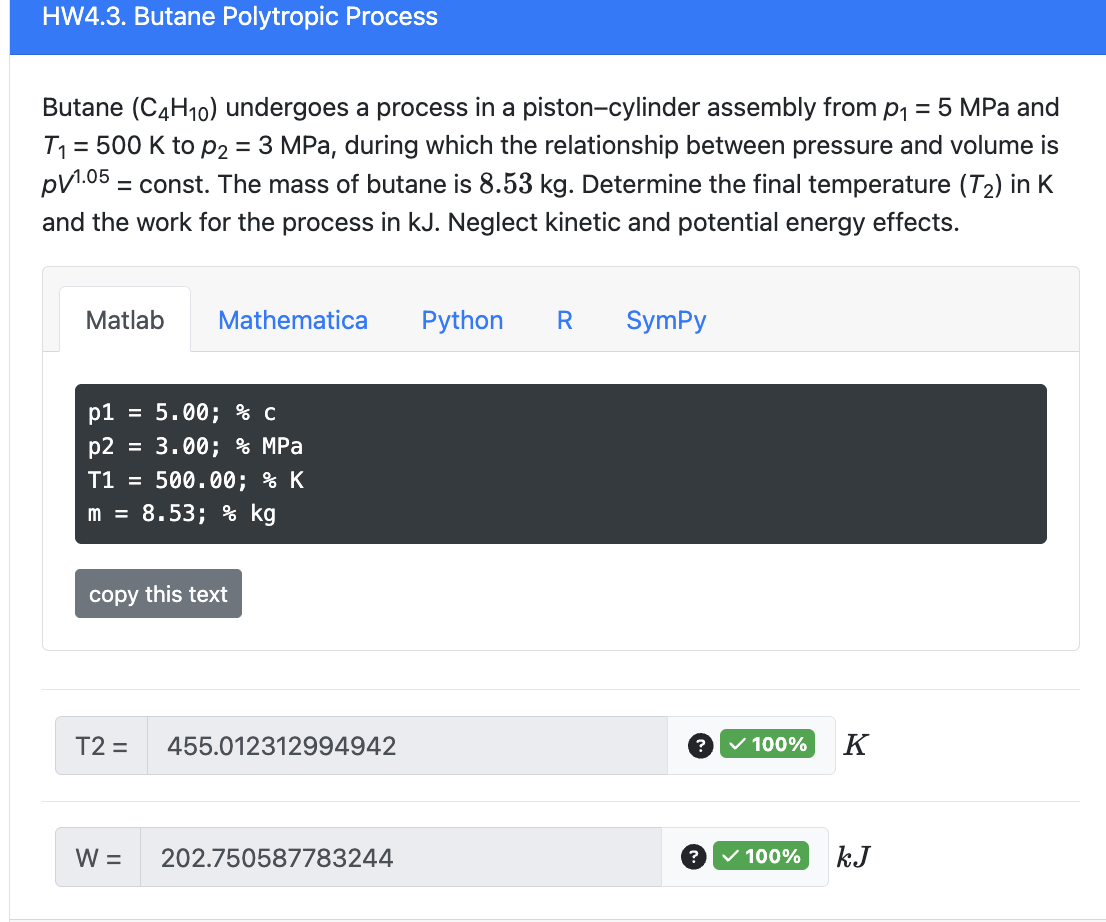

In [3]:
# 4.3
# 思路
# 第一状态 p1 t1已知 算pr tr读图得到z1 用z1=p1*v1/R/t1得到v1
# 用 pv**(1.05)固定，p1,p2,v1已知算出v2
# 第二状态 p2 v2已知 用vr=v2*pc/tc/R得到vr 算vr，pr读图得到z2 用z2=p2*v2/R/t2得到t2
# W=integrate(p*m,(v,v1,v2))

import numpy as np

p1 = 5.00 # c
p2 = 3.00 # MPa
T1 = 500.00 # K
m = 8.53 # kg
# ===================


pc=3.8e5 
tc=425 # K

p1=p1*1e5
p2=p2*1e5
R=8314/58



pr=p1/pc
tr=T1/tc
# print(pr,tr)
#读图
z1=0.69
v1=z1/p1*R*T1
# print(v1)

c=p1*v1**1.05
v2=(c/p2)**(1/1.05)
# print(v2)


from sympy import *
v=S('v')
w=integrate(c/v**1.05*m,(v,v1,v2))
# print(w)


vr=v2*pc/tc/R
pr2=p2/pc
# print(vr,pr2)
# 读图
z2=0.74
t2=p2*v2/R/z2
# print(t2)


print(t2,w/1e3)

455.012312994942 202.750587783244


![屏幕截图 2026-03-15 104137.png](<attachment:屏幕截图 2026-03-15 104137.png>)
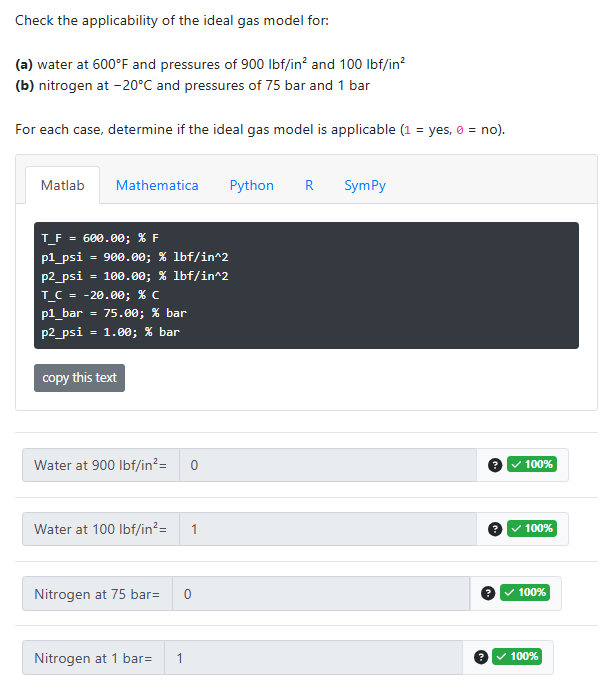

In [4]:
#4.3NEW
from CoolProp.CoolProp import PropsSI

T_F = 600.00 # F
p1_psi = 900.00 # lbf/in^2
p2_psi = 100.00 # lbf/in^2
T_C = -20.00 # C
p1_bar = 75.00 # bar
p2_bar = 1.00#bar #此处原题变量名有误，需手动更正

# Define all test cases
cases = [
    {"name": "Water at 900 lbf/in²", "fluid": "Water", "T": T_F, "T_unit": "F", "P": p1_psi, "P_unit": "psi"},
    {"name": "Water at 100 lbf/in²", "fluid": "Water", "T": T_F, "T_unit": "F", "P": p2_psi, "P_unit": "psi"},
    {"name": "Nitrogen at 75 bar", "fluid": "Nitrogen", "T": T_C, "T_unit": "C", "P": p1_bar, "P_unit": "bar"},
    {"name": "Nitrogen at 1 bar", "fluid": "Nitrogen", "T": T_C, "T_unit": "C", "P": p2_bar, "P_unit": "bar"},
]

# Ideal gas applicability threshold: Z within 5% of 1
Z_MIN = 0.95
Z_MAX = 1.05

# Process each case
for case in cases:
    # Convert temperature to absolute Kelvin
    if case["T_unit"] == "F":
        T_K = (case["T"] - 32) * 5/9 + 273.15
    elif case["T_unit"] == "C":
        T_K = case["T"] + 273.15
    
    # Convert pressure to absolute Pascals
    if case["P_unit"] == "psi":
        P_Pa = case["P"] * 6894.76  # 1 psi = 6894.76 Pa
    elif case["P_unit"] == "bar":
        P_Pa = case["P"] * 1e5  # 1 bar = 100,000 Pa
    
    # Calculate compressibility factor Z
    Z = PropsSI("Z", "T", T_K, "P", P_Pa, case["fluid"])
    
    # Determine if ideal gas is applicable (1 = yes, 0 = no)
    ideal_applicable = 1 if (Z >= Z_MIN and Z <= Z_MAX) else 0
    
    # Print results
    print(f"{case['name']}: Z = {Z:.4f}, Ideal gas applicable = {ideal_applicable}")

    #75bar 的答案应该是0，但我也不知道为什么

Water at 900 lbf/in²: Z = 0.8377, Ideal gas applicable = 0
Water at 100 lbf/in²: Z = 0.9848, Ideal gas applicable = 1
Nitrogen at 75 bar: Z = 0.9644, Ideal gas applicable = 1
Nitrogen at 1 bar: Z = 0.9993, Ideal gas applicable = 1


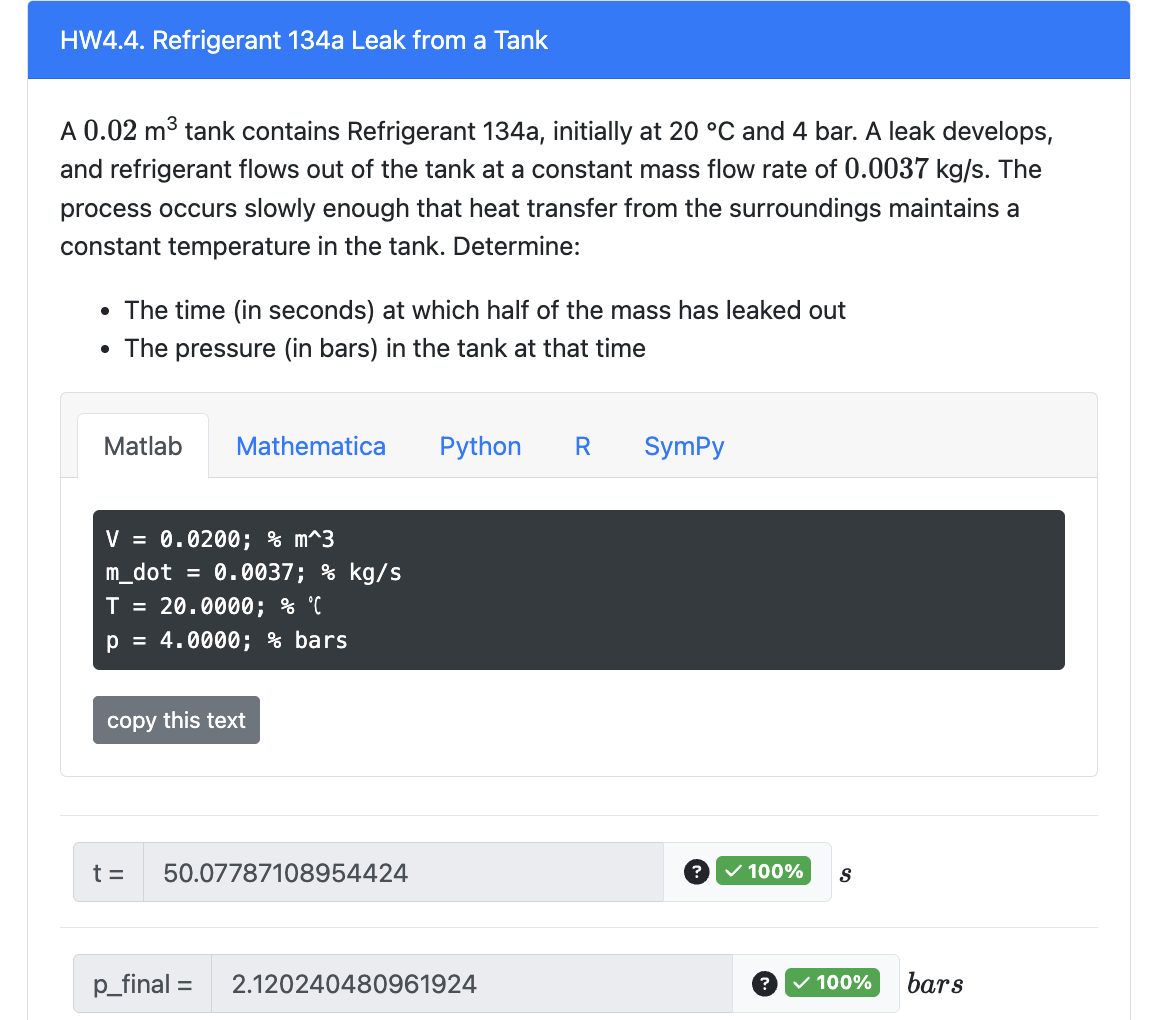

In [5]:
# 4.4
# 思路 
# 第一阶段气体 p1 t1已知 读表v1 算m=V/v1 
# 第二阶段气体 v2 t2已知 读表得p2

from sympy import *

V = 0.0400 # m^3
m_dot = 0.0036 # kg/s
T = 20.0000 # ℃
p = 4.0000 # bars
# =============================

v1=0.05397  

m = V/v1 # kg 
t = m/2/m_dot

v2 = V/(m/2)
print(v2)
p_final = (v2-0.11394)/(0.09399-0.11395)*(2.4-2)+2

print(t,p_final)


0.10794
102.93784612850762 2.120240480961924


![屏幕截图 2026-03-15 104508.png](<attachment:屏幕截图 2026-03-15 104508.png>)
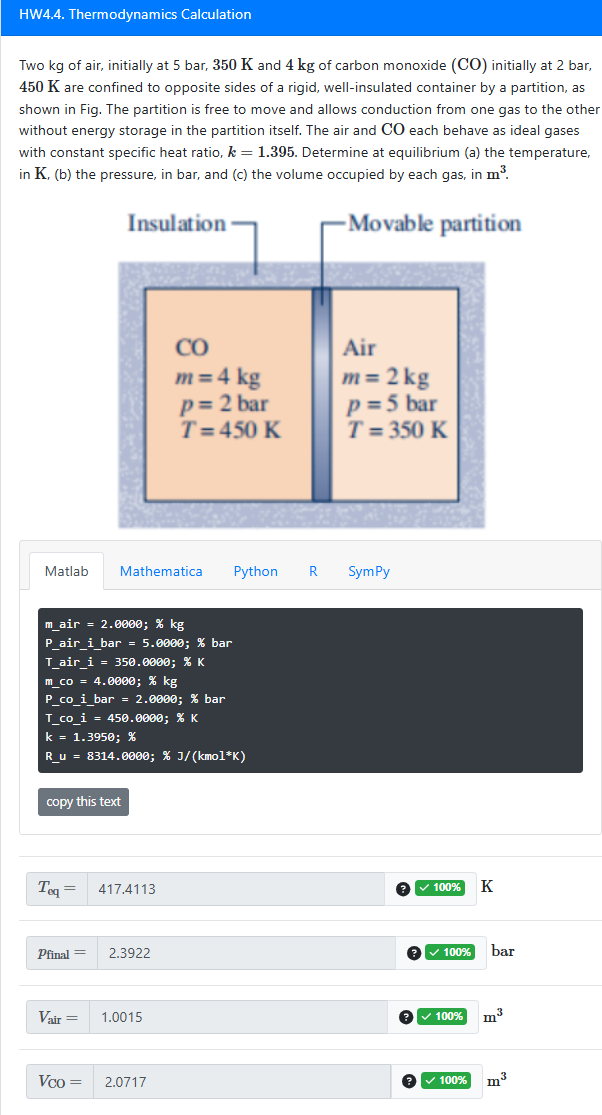

In [6]:
#4.4 new
# ----------------------
# Given Input Parameters
# ----------------------
m_air = 2.0000       # Mass of air, kg
P_air_i_bar = 5.0000 # Initial pressure of air, bar
T_air_i = 350.0000   # Initial temperature of air, K

m_co = 4.0000        # Mass of CO, kg
P_co_i_bar = 2.0000  # Initial pressure of CO, bar
T_co_i = 450.0000    # Initial temperature of CO, K

k = 1.3950            # Specific heat ratio (Cp/Cv) for both gases
R_u = 8314.0000       # Universal gas constant, J/(kmol·K)

# Molar masses (standard values)
M_air = 28.97  # Molar mass of air, kg/kmol
M_co = 28.01   # Molar mass of carbon monoxide, kg/kmol

# ----------------------
# Step 1: Calculate Specific Gas Constants (R) and Cv for each gas
# ----------------------
# Specific gas constant R = R_u / M (units: J/(kg·K))
R_air = R_u / M_air
R_co = R_u / M_co

# Cv from k = Cp/Cv = (Cv + R)/Cv → Cv = R/(k-1)
Cv_air = R_air / (k - 1)
Cv_co = R_co / (k - 1)

# ----------------------
# Step 2: Solve Equilibrium Temperature (T_eq) from Energy Balance
# ----------------------
# Total internal energy change is zero (insulated, rigid container: Q=0, W=0)
# ΔU_air + ΔU_co = 0 → m_air*Cv_air*(T_eq - T_air_i) + m_co*Cv_co*(T_eq - T_co_i) = 0
numerator_T = m_air * Cv_air * T_air_i + m_co * Cv_co * T_co_i
denominator_T = m_air * Cv_air + m_co * Cv_co
T_eq = numerator_T / denominator_T

# ----------------------
# Step 3: Calculate Total Volume of the Container
# ----------------------
# Convert initial pressures from bar to Pa (1 bar = 1e5 Pa)
P_air_i = P_air_i_bar * 1e5
P_co_i = P_co_i_bar * 1e5

# Initial volumes from ideal gas law: PV = mRT → V = mRT/P
V_air_i = (m_air * R_air * T_air_i) / P_air_i
V_co_i = (m_co * R_co * T_co_i) / P_co_i
V_total = V_air_i + V_co_i

# ----------------------
# Step 4: Solve Equilibrium Pressure (P_eq)
# ----------------------
# At equilibrium: P_eq is equal for both gases, T_eq is equal for both gases
# Total volume: V_total = V_air_eq + V_co_eq = (T_eq / P_eq) * (m_air*R_air + m_co*R_co)
term = m_air * R_air + m_co * R_co
P_eq_Pa = (T_eq * term) / V_total
P_eq_bar = P_eq_Pa / 1e5  # Convert back to bar

# ----------------------
# Step 5: Calculate Equilibrium Volumes for each gas
# ----------------------
V_air_eq = (m_air * R_air * T_eq) / P_eq_Pa
V_co_eq = (m_co * R_co * T_eq) / P_eq_Pa

# ----------------------
# Print Final Results
# ----------------------
print("=== Equilibrium Results ===")
print(f"Equilibrium Temperature (T_eq): {T_eq:.4f} K")
print(f"Equilibrium Pressure (P_final): {P_eq_bar:.4f} bar")
print(f"Equilibrium Volume of Air (V_air): {V_air_eq:.4f} m³")
print(f"Equilibrium Volume of CO (V_CO): {V_co_eq:.4f} m³")

=== Equilibrium Results ===
Equilibrium Temperature (T_eq): 417.4113 K
Equilibrium Pressure (P_final): 2.3922 bar
Equilibrium Volume of Air (V_air): 1.0015 m³
Equilibrium Volume of CO (V_CO): 2.0717 m³


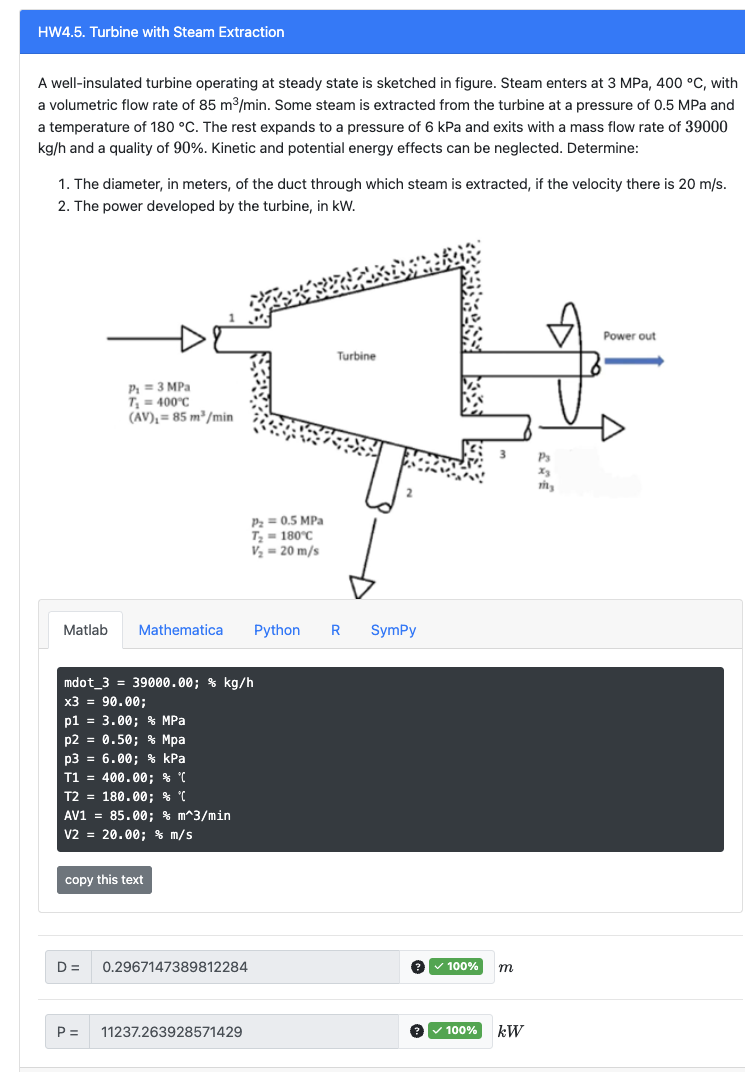

In [10]:
# 4.5

import math as m
import numpy as np
from sympy import *

mdot_3 = 39000.00 # kg/h
x3 = 89.00
p1 = 3.00 # MPa
p2 = 0.50 # Mpa
p3 = 6.00 # kPa
T1 = 400.00 # ℃
T2 = 180.00 # ℃
AV1 = 85.00 # m^3/min
V2 = 20.00 # m/s

x3=x3/100

#提取处管道指的是2号管道
m1 = AV1/0.0994/60 # 体积比容(m**3/min)/比容(m**3/kg)=质量流量每分钟(kg/min)
m3 = mdot_3/3600 # 质量流量每分钟

# 质量流量×比容=体积流量 
# 体积流量/速度-面积
s = (m1-m3)*0.4045/V2
d = m.sqrt(s/m.pi*4)


#-----------------------------------------------------------
# 这里查表 
#利用焓来计算
# 过热气体 t=400 p=3mpa
h1 = 3230.9
# 过热气体 t=180 p=0.5mpa
h2 = 2812.0

# 混合物 p=0.06 t=36.16 、
hl=151.53
hg=2567.4
# x是gas的占比
h3 = (1-x3)*hl+(x3)*hg

# print(h3)
# 因为h的单位是kj/kg所以单位不需要变，w就是kw
w = m1*h1-m3*h3-(m1-m3)*h2
d,w


(0.2967147389812284, 11498.983178571427)

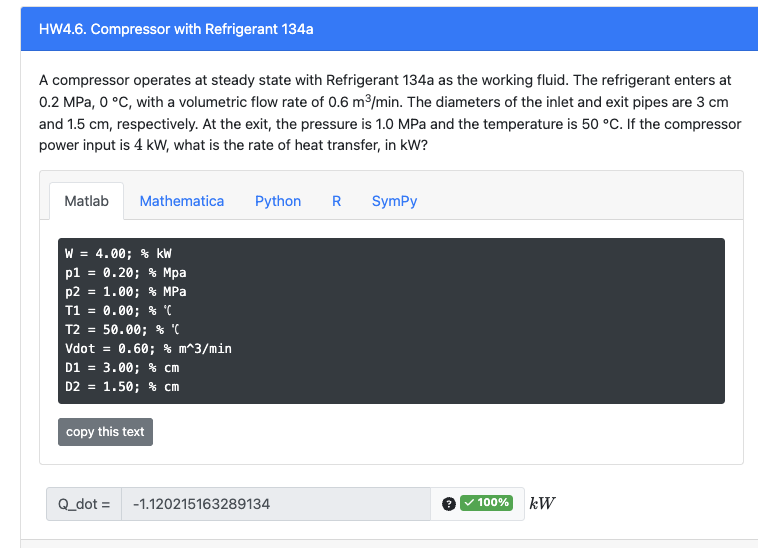

In [11]:
# 4.6
import math as m
import numpy as np

from sympy import *

W = 4.00 # kW
p1 = 0.20 # Mpa
p2 = 1.00 # MPa
T1 = 0.00 # ℃
T2 = 50.00 # ℃
Vdot = 0.60 # m^3/min
D1 = 3.00 # cm
D2 = 1.50 # cm
#------------------------------------
m1 = Vdot/60/0.10438 #kg/s


#因为1Mpa小于12bar，所以还是气态
#进去多少就出来多少，所以m3 = m1
m3 = m1
s1 = m.pi*(D1/2/100)**2
s2 = m.pi*(D2/2/100)**2

v1 = Vdot/60/s1
v3 = m3*0.02171/s2


h1 = 250.1
h3 = 280.19
Q = -(W+m1*h1-m1*h3-m1*(v3**2-v1**2)/2000)
Q


-1.120215163289134

![屏幕截图 2026-03-15 105413.png](<attachment:屏幕截图 2026-03-15 105413.png>)
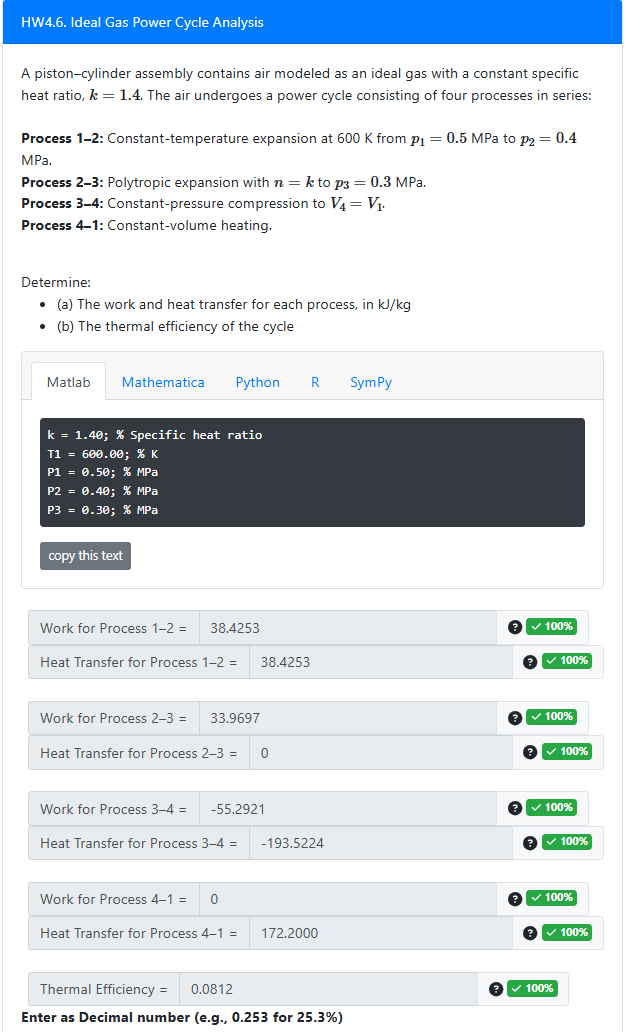

In [12]:
import math

# ----------------------
# Given Input Parameters
# ----------------------
k = 1.40          # Specific heat ratio (Cp/Cv) for air
T1 = 600.00       # Temperature at state 1, K
P1 = 0.50         # Pressure at state 1, MPa
P2 = 0.40         # Pressure at state 2, MPa
P3 = 0.30         # Pressure at state 3, MPa

# Air thermodynamic properties (standard values)
R = 0.287         # Specific gas constant, kJ/(kg·K) = kPa·m³/(kg·K)
Cv = R / (k - 1)  # Constant volume specific heat, kJ/(kg·K)
Cp = k * Cv       # Constant pressure specific heat, kJ/(kg·K)

# Convert pressures from MPa to kPa (1 MPa = 1000 kPa)
P1_kPa = P1 * 1000
P2_kPa = P2 * 1000
P3_kPa = P3 * 1000
P4_kPa = P3_kPa  # Process 3-4 is constant pressure

# ----------------------
# Step 1: State 1
# ----------------------
v1 = R * T1 / P1_kPa  # Specific volume, m³/kg

# ----------------------
# Step 2: Process 1-2: Isothermal Expansion (T2 = T1)
# ----------------------
T2 = T1
v2 = R * T2 / P2_kPa
w12 = R * T1 * math.log(P1_kPa / P2_kPa)
q12 = w12  # Δu = 0 for isothermal ideal gas

# ----------------------
# Step 3: Process 2-3: Polytropic Expansion (n = k, isentropic)
# ----------------------
# Isentropic relation: P2*v2^k = P3*v3^k → v3 = v2*(P2/P3)^(1/k)
v3 = v2 * (P2_kPa / P3_kPa) ** (1/k)
T3 = P3_kPa * v3 / R  # Ideal gas law for T3
w23 = R * (T2 - T3) / (k - 1)  # Polytropic work formula
q23 = 0.0  # Adiabatic process

# ----------------------
# Step 4: Process 3-4: Constant Pressure Compression (v4 = v1)
# ----------------------
v4 = v1
T4 = T3 * (v4 / v3)  # Constant P: v/T = constant
w34 = P3_kPa * (v4 - v3)  # No division by 1000! (kPa·m³/kg = kJ/kg)
q34 = Cp * (T4 - T3)

# ----------------------
# Step 5: Process 4-1: Constant Volume Heating
# ----------------------
w41 = 0.0  # Constant volume: no work
q41 = Cv * (T1 - T4)

# ----------------------
# Step 6: Cycle Thermal Efficiency
# ----------------------
w_net = w12 + w23 + w34 + w41
q_in = sum(q for q in [q12, q23, q34, q41] if q > 0)
eta = w_net / q_in

# ----------------------
# Print Final Results
# ----------------------
print("=== Process Work and Heat Transfer (per unit mass, kJ/kg) ===")
print(f"Work for Process 1-2: {w12:.4f}")
print(f"Heat Transfer for Process 1-2: {q12:.4f}")
print()
print(f"Work for Process 2-3: {w23:.4f}")
print(f"Heat Transfer for Process 2-3: {q23:.4f}")
print()
print(f"Work for Process 3-4: {w34:.4f}")
print(f"Heat Transfer for Process 3-4: {q34:.4f}")
print()
print(f"Work for Process 4-1: {w41:.4f}")
print(f"Heat Transfer for Process 4-1: {q41:.4f}")
print()
print("=== Cycle Performance ===")
print(f"Thermal Efficiency: {eta:.4f}")

=== Process Work and Heat Transfer (per unit mass, kJ/kg) ===
Work for Process 1-2: 38.4253
Heat Transfer for Process 1-2: 38.4253

Work for Process 2-3: 33.9697
Heat Transfer for Process 2-3: 0.0000

Work for Process 3-4: -55.2921
Heat Transfer for Process 3-4: -193.5224

Work for Process 4-1: 0.0000
Heat Transfer for Process 4-1: 172.2000

=== Cycle Performance ===
Thermal Efficiency: 0.0812
